# Imports

In [1]:
%load_ext autoreload
%autoreload 2

import logging
import numpy as np
import matplotlib.pyplot as plt

import msml610_utils as ut

ut.config_notebook()

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
vim support installed: restart the notebook, if needed


Python 3.12.3
Linux 7d77d2247121 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 aarch64 aarch64 GNU/Linux


In [5]:
import helpers.hio as hio
import L09_05_04_non_linear_kalman_filter_utils as time_ut

dst_dir = "figures"
hio.create_dir(dst_dir, incremental=True)
# cp msml610/tutorials/figures/*.png msml610/lectures_source/figures

In [6]:
!sudo /bin/bash -c "(source /venv/bin/activate; pip install --quiet filterpy)"

import filterpy

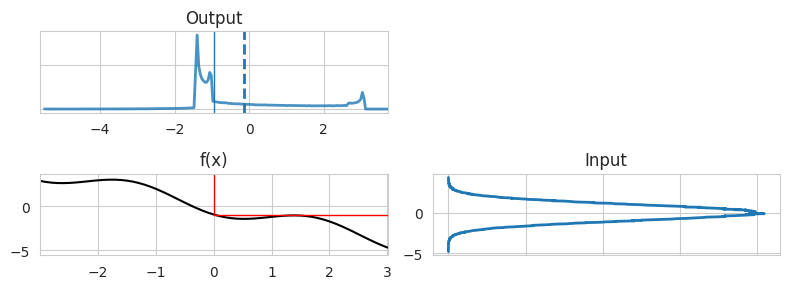

In [8]:
from numpy.random import normal
import numpy as np

# create 500,000 samples with mean 0, std 1
gaussian = (0., 1.)
data = normal(loc=gaussian[0], scale=gaussian[1], size=500000)

def f(x):
    return (np.cos(4*(x/2 + 0.7))) - 1.3*x
    
time_ut.plot_nonlinear_func(data, f)

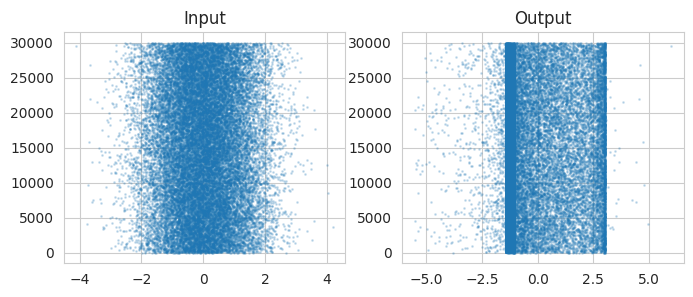

In [9]:
N = 30000
plt.subplot(121)
plt.scatter(data[:N], range(N), alpha=.2, s=1)
plt.title('Input')
plt.subplot(122)
plt.title('Output')
plt.scatter(f(data[:N]), range(N), alpha=.2, s=1);

Difference in mean x=0.064, y=43.084


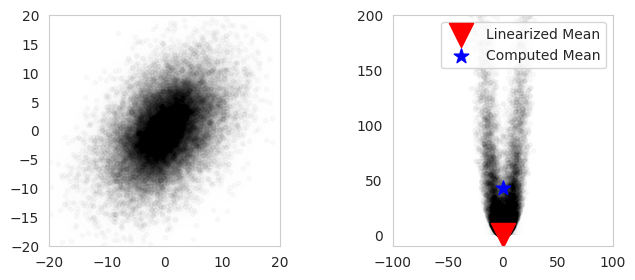

In [13]:
import numpy as np
from numpy.random import multivariate_normal

def f_nonlinear_xy(x, y):
    return np.array([x + y, .1*x**2 + y*y])

# Generate random points from a multivariate.
N = 10000
mean = (0., 0.)
p = np.array([[32., 15.], [15., 40.]])
xs, ys = multivariate_normal(mean=mean, cov=p, size=N).T

# Compute linearized mean
mean_fx = f_nonlinear_xy(*mean)

time_ut.plot_monte_carlo_mean(xs, ys, f_nonlinear_xy, mean_fx, 'Linearized Mean');